In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ─── Helper functions ─────────────────────────────────────────────────────────

def extract_analysis_channel(img):
    """Return the validation channel (Lab L* for RGB images)."""
    if img.ndim == 2:
        return img
    return cv2.cvtColor(img, cv2.COLOR_RGB2LAB)[:, :, 0]


def apply_gamma_lab(img_rgb_in, gamma=0.40):
    """Apply gamma correction to the L* channel in CIE-Lab and return an RGB image."""
    lab = cv2.cvtColor(img_rgb_in, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    l_norm = l_channel.astype(np.float32) / 255.0
    l_gamma = np.uint8(np.clip(255 * np.power(l_norm, gamma), 0, 255))
    lab_gamma = cv2.merge((l_gamma, a_channel, b_channel))
    return cv2.cvtColor(lab_gamma, cv2.COLOR_LAB2RGB)


def show_grid(images, titles, figsize=(22, 4), cmap=None):
    """Display a row of images with titles."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def show_validation_histograms(stages, title):
    """Plot histogram and CDF on Lab L* using twin y-axes for readability."""
    fig, axes = plt.subplots(1, len(stages), figsize=(22, 5))
    if len(stages) == 1:
        axes = [axes]

    for ax, (name, img_s) in zip(axes, stages.items()):
        channel = extract_analysis_channel(img_s)
        hist_s = np.bincount(channel.flatten(), minlength=256)
        cdf_s = hist_s.cumsum() / hist_s.sum()
        ax2 = ax.twinx()

        ax.bar(np.arange(256), hist_s, width=1.0, color='steelblue', alpha=0.85)
        ax2.step(np.arange(256), cdf_s, where='mid', color='crimson', linewidth=1.5, label='CDF')

        ax.set_title(name, fontsize=8)
        ax.set_xlabel('Canal L*', fontsize=8)
        ax.set_ylabel('Frecuencia')
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.15)

        ax2.set_ylim(0, 1.02)
        ax2.set_ylabel('CDF', color='crimson')
        ax2.tick_params(axis='y', colors='crimson')
        ax2.legend(loc='lower right', fontsize=6)

    plt.suptitle(f'{title} — Histograma + CDF del canal L*', fontsize=12)
    plt.tight_layout()
    plt.show()

# Imagen 1: 1187.png

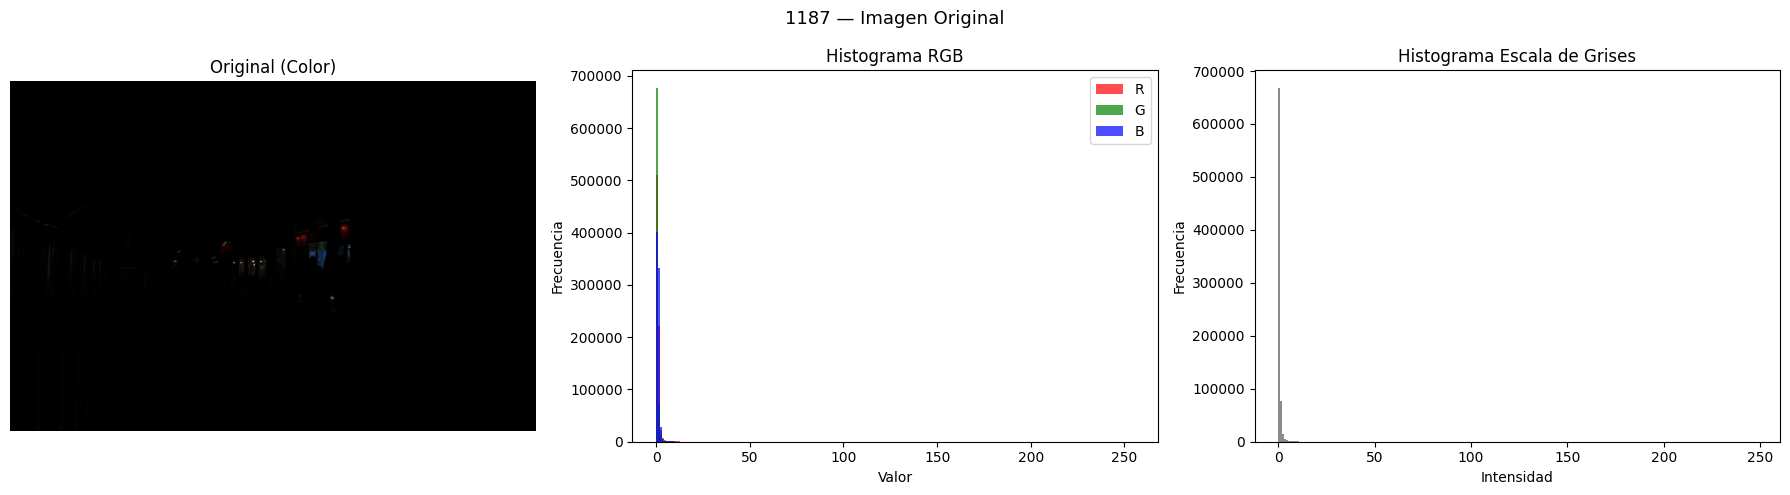

Resolución: 720×1080  |  Rango: [0, 248]  |  Media: 0.4  |  Std: 2.7


In [2]:
# ── Carga ─────────────────────────────────────────────────────────────────────
img_bgr  = cv2.imread("./images/1187.png")
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ── Visualización original + histogramas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original (Color)")
axes[0].axis("off")

for i, (c, label) in enumerate(zip("rgb", ("R", "G", "B"))):
    axes[1].hist(img_rgb[:, :, i].flatten(), bins=256, color=c, alpha=0.7, label=label)
axes[1].set_title("Histograma RGB")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

axes[2].hist(img_gray.flatten(), bins=256, color="gray", alpha=0.9)
axes[2].set_title("Histograma Escala de Grises")
axes[2].set_xlabel("Intensidad")
axes[2].set_ylabel("Frecuencia")

plt.suptitle("1187 — Imagen Original", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Resolución: {img_gray.shape[0]}×{img_gray.shape[1]}  |  "
      f"Rango: [{img_gray.min()}, {img_gray.max()}]  |  "
      f"Media: {img_gray.mean():.1f}  |  Std: {img_gray.std():.1f}")


## 1.1 Objetivo del Proceso

Capturar la información relevante de la imagen original **`1187.png`** para facilitar la extracción de información posterior, ya sea por un observador humano o una máquina.

El procesado se estructura en un flujo de dos pasos encadenados:

| Paso | Técnica | Propósito |
|------|---------|----------|
| **1** | Corrección gamma sobre L* en CIE-Lab | Expandir el rango de los píxeles oscuros preservando mejor la cromaticidad |
| **2** | CLAHE LAB | Mejora de contraste local en espacio perceptual CIE-Lab |

## 1.2 Paso 1 – Ajuste de Intensidad (Corrección Gamma sobre L* en CIE-Lab)

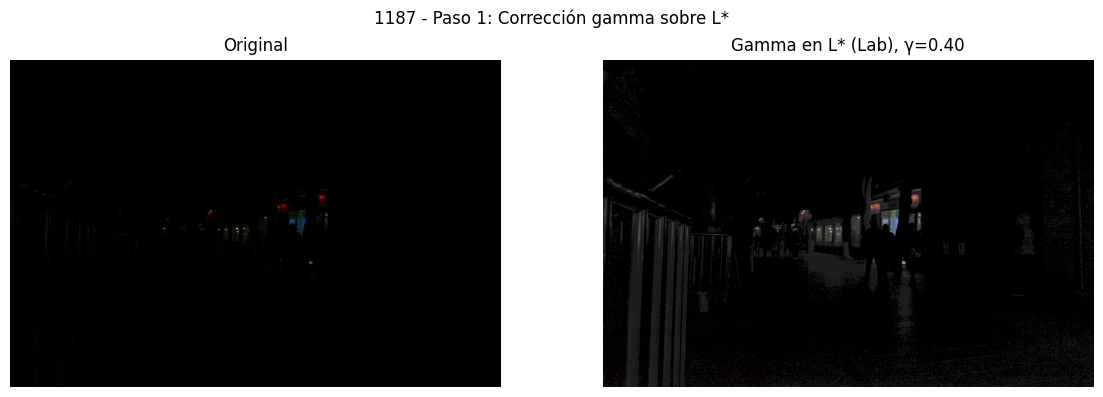

In [3]:
# Paso 1: Corrección gamma sobre el canal L* de CIE-Lab (gamma=0.40)
# gamma=0.40 seleccionado: 1187 es la imagen más oscura del conjunto, con el 90%
# de los píxeles por debajo de 20. Aplicar la ley de potencia sobre L* permite
# realzar la luminancia preservando mejor la cromaticidad que una gamma en RGB.

step1 = apply_gamma_lab(img_rgb, gamma=0.40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(step1); axes[1].set_title('Gamma en L* (Lab), γ=0.40'); axes[1].axis('off')
plt.suptitle('1187 - Paso 1: Corrección gamma sobre L*', fontsize=12)
plt.tight_layout()
plt.show()

## 1.3 Paso 2 - CLAHE LAB

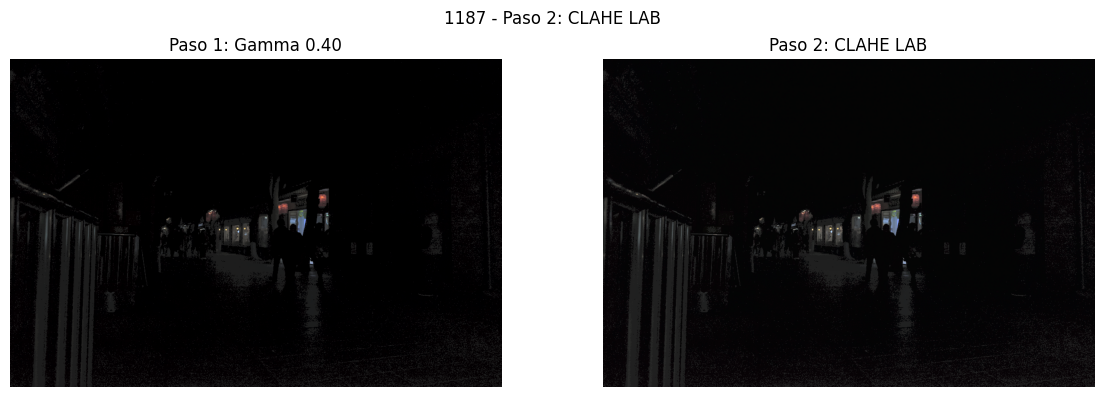

In [ ]:
# Paso 2: CLAHE LAB
# clipLimit=2.0, tileGridSize=(8,8): parámetros estándar sobre la salida gamma en L*.

def clahe_lab(img_rgb_in, clip_limit=2.0, tile_grid=(8, 8)):
    """CLAHE on L channel (CIE-Lab)."""
    lab = cv2.cvtColor(img_rgb_in, cv2.COLOR_RGB2LAB)
    L_ch, A_ch, B_ch = cv2.split(lab)
    clahe_obj = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    return cv2.cvtColor(cv2.merge((clahe_obj.apply(L_ch), A_ch, B_ch)), cv2.COLOR_LAB2RGB)

step2 = clahe_lab(step1, clip_limit=2.0, tile_grid=(8, 8))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(step1); axes[0].set_title('Paso 1: Gamma en L* (γ=0.40)'); axes[0].axis('off')
axes[1].imshow(step2); axes[1].set_title('Paso 2: CLAHE LAB'); axes[1].axis('off')
plt.suptitle('1187 - Paso 2: CLAHE LAB', fontsize=12)
plt.tight_layout()
plt.show()

## 1.4 Validación

La validación se representa sobre el canal L* de Lab mediante histogramas y CDF.

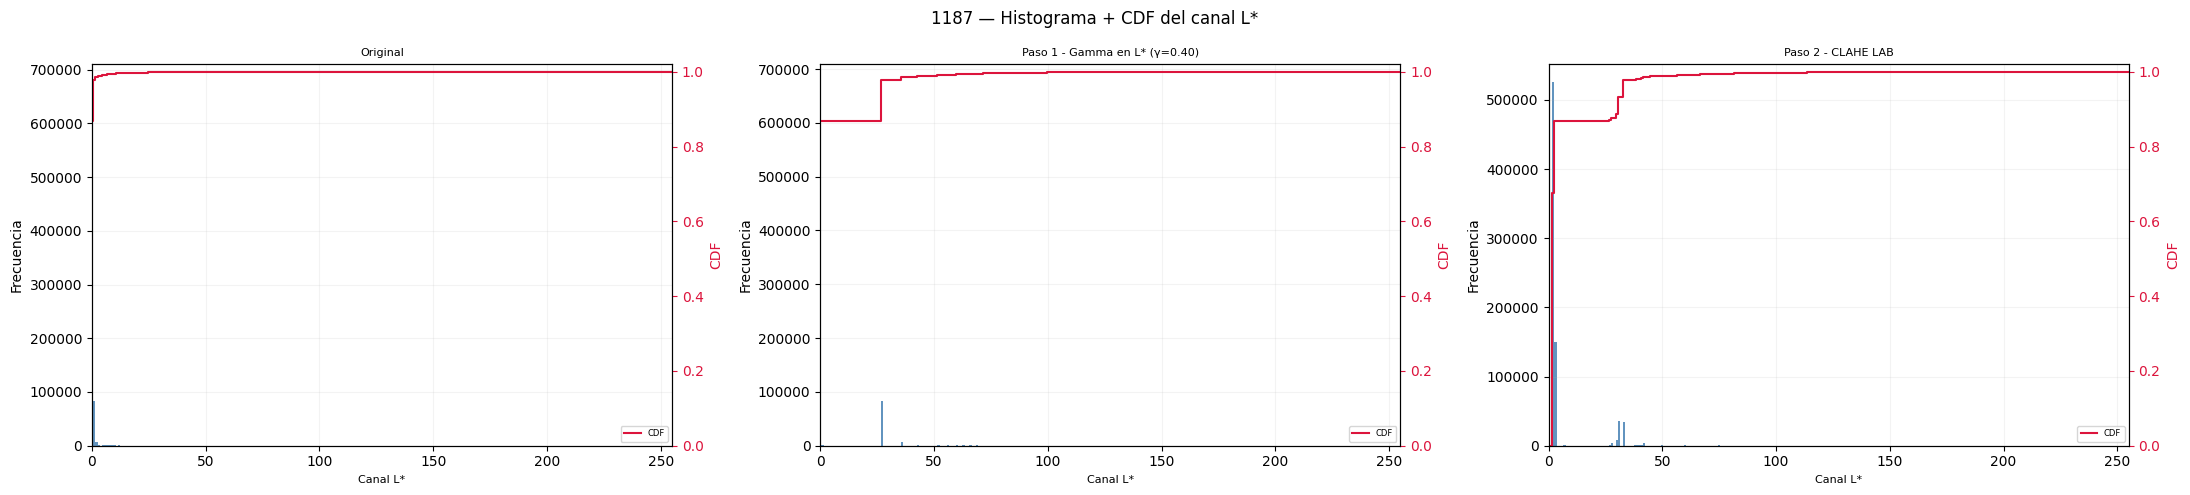

In [5]:
stages_1187 = {
    'Original': img_rgb,
    'Paso 1 - Gamma en L* (γ=0.40)': step1,
    'Paso 2 - CLAHE LAB': step2,
}
show_validation_histograms(stages_1187, '1187')

# Imagen 2: 1321.png

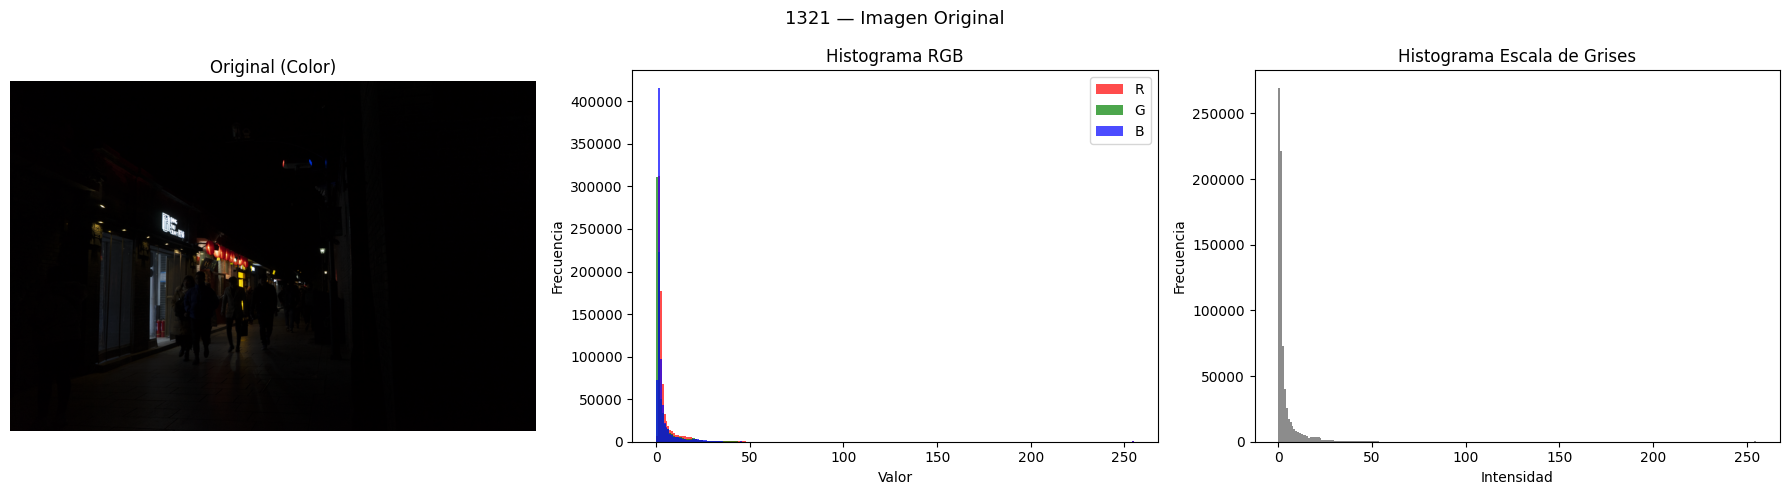

Resolución: 720×1080  |  Rango: [0, 255]  |  Media: 4.5  |  Std: 14.8


In [77]:
# ── Carga ─────────────────────────────────────────────────────────────────────
img_bgr  = cv2.imread("./images/1321.png")
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ── Visualización original + histogramas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original (Color)")
axes[0].axis("off")

for i, (c, label) in enumerate(zip("rgb", ("R", "G", "B"))):
    axes[1].hist(img_rgb[:, :, i].flatten(), bins=256, color=c, alpha=0.7, label=label)
axes[1].set_title("Histograma RGB")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

axes[2].hist(img_gray.flatten(), bins=256, color="gray", alpha=0.9)
axes[2].set_title("Histograma Escala de Grises")
axes[2].set_xlabel("Intensidad")
axes[2].set_ylabel("Frecuencia")

plt.suptitle("1321 — Imagen Original", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Resolución: {img_gray.shape[0]}×{img_gray.shape[1]}  |  "
      f"Rango: [{img_gray.min()}, {img_gray.max()}]  |  "
      f"Media: {img_gray.mean():.1f}  |  Std: {img_gray.std():.1f}")


## 2.1 Objetivo del Proceso

Capturar la información relevante de la imagen original **`1321.png`** para facilitar la extracción de información posterior.

El procesado se estructura en un flujo de dos pasos encadenados:

| Paso | Técnica | Propósito |
|------|---------|----------|
| **1** | Transformación Logarítmica | Expandir el rango de los píxeles oscuros de forma no lineal |
| **2** | CLAHE LAB | Mejora de contraste local en espacio perceptual CIE-Lab |

## 2.2 Paso 1 - Transformación Logarítmica

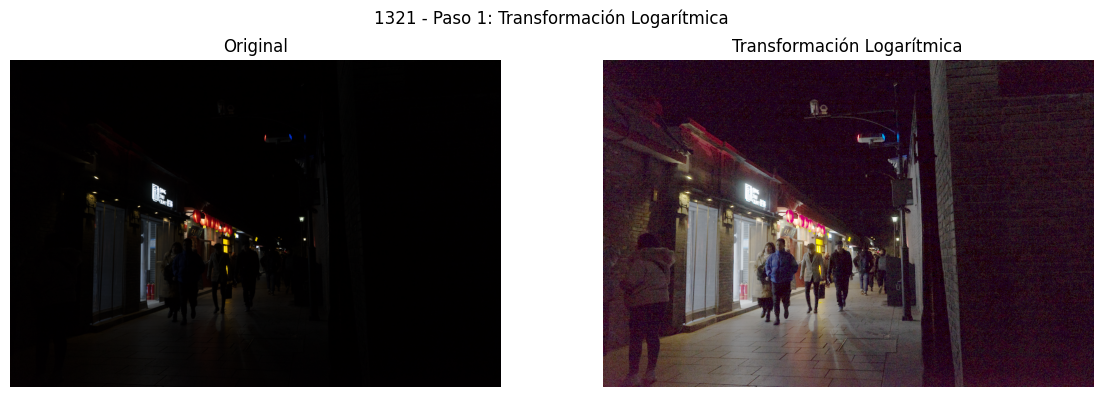

In [78]:
# Paso 1: Transformacion Logaritmica (s = c*log10(1+r))
# c = 255/log10(256) normaliza la salida al rango [0, 255].

c_log = 255 / np.log10(1 + 255)
step1 = np.uint8(np.clip(c_log * np.log10(1 + img_rgb.astype(np.float32)), 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(step1); axes[1].set_title('Transformación Logarítmica'); axes[1].axis('off')
plt.suptitle('1321 - Paso 1: Transformación Logarítmica', fontsize=12)
plt.tight_layout()
plt.show()

## 2.3 Paso 2 - CLAHE LAB

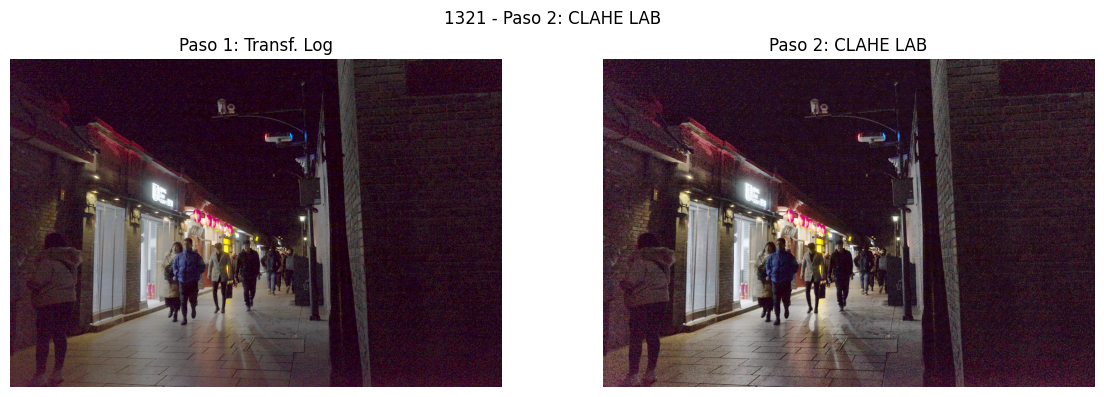

In [79]:
# Paso 2: CLAHE LAB
# clipLimit=2.0, tileGridSize=(8,8): parametros estandar.

step2 = clahe_lab(step1, clip_limit=2.0, tile_grid=(8, 8))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(step1); axes[0].set_title('Paso 1: Transf. Log'); axes[0].axis('off')
axes[1].imshow(step2); axes[1].set_title('Paso 2: CLAHE LAB'); axes[1].axis('off')
plt.suptitle('1321 - Paso 2: CLAHE LAB', fontsize=12)
plt.tight_layout()
plt.show()

## 2.4 Validación

La validación se representa sobre el canal L* de Lab mediante histogramas y CDF.

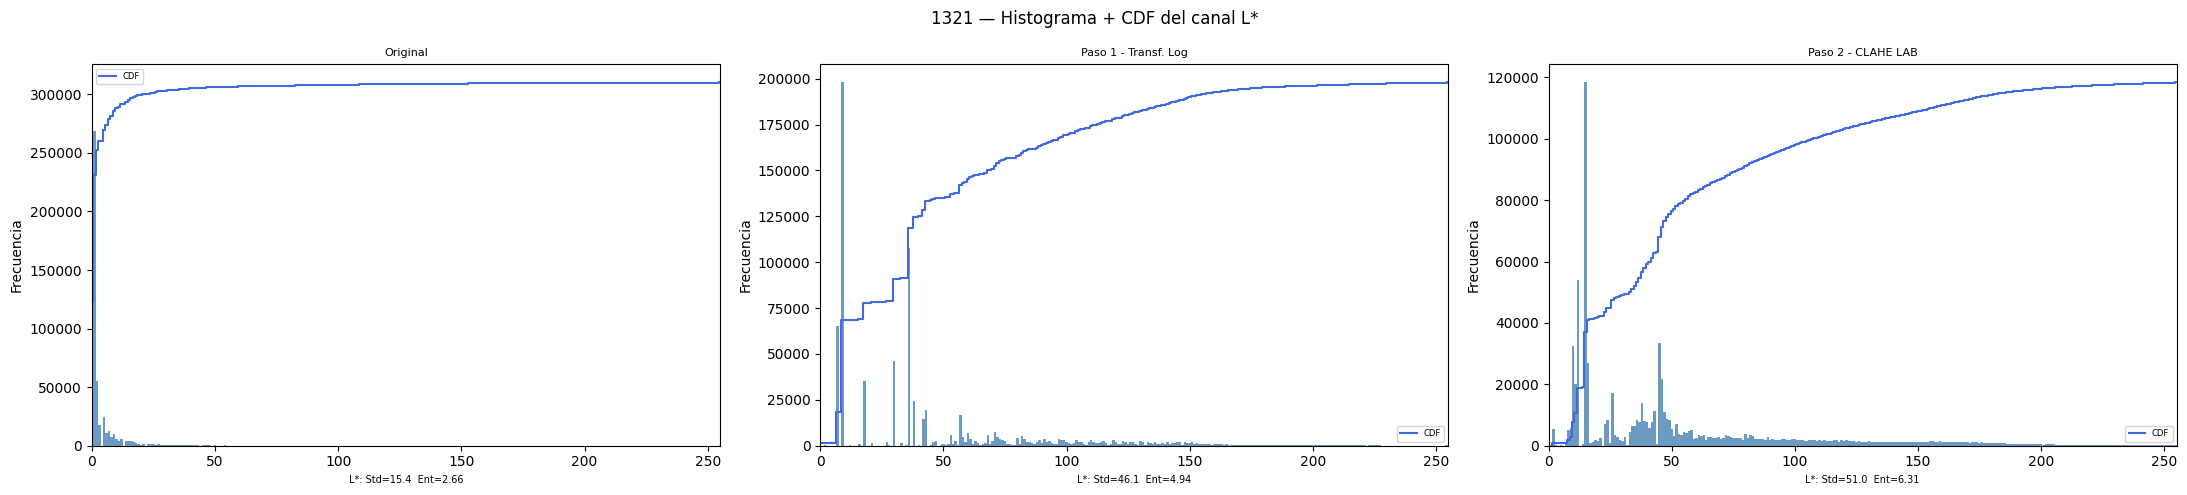

In [ ]:
stages_1321 = {
    'Original': img_rgb,
    'Paso 1 - Transf. Log': step1,
    'Paso 2 - CLAHE LAB': step2,
}
show_validation_histograms(stages_1321, '1321')

# Imagen 3: 1457.png

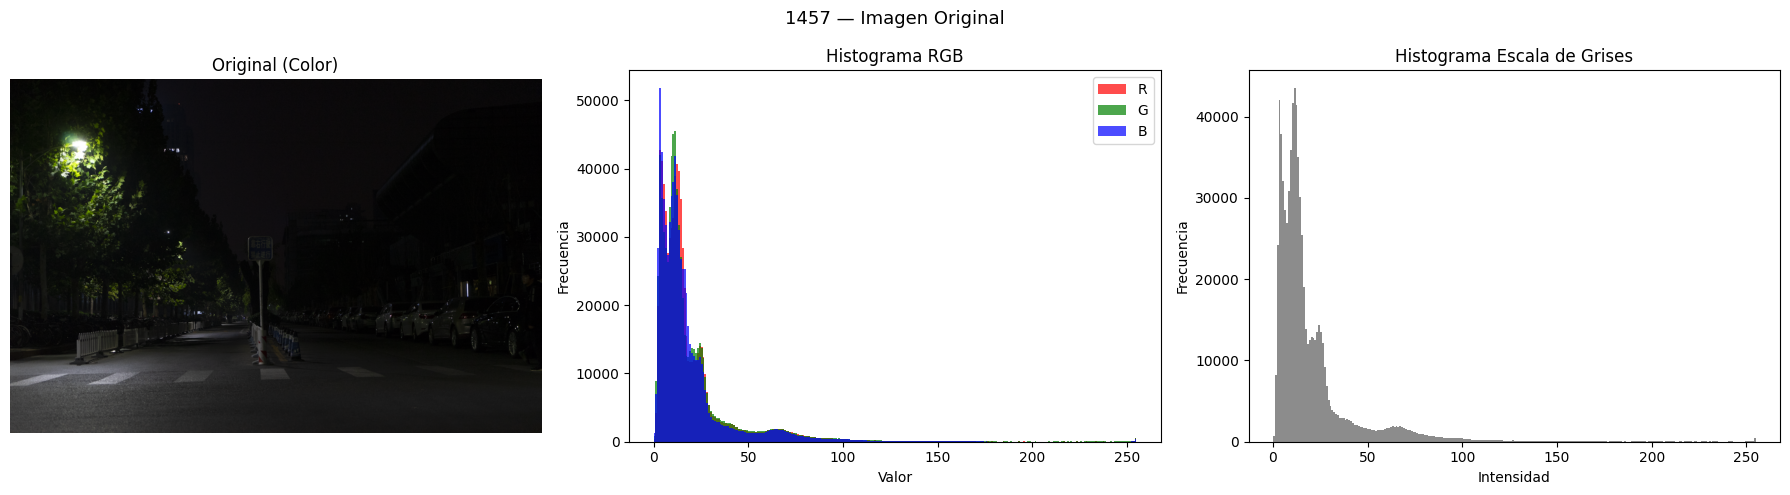

Resolución: 720×1080  |  Rango: [0, 255]  |  Media: 20.0  |  Std: 24.6


In [81]:
# ── Carga ─────────────────────────────────────────────────────────────────────
img_bgr  = cv2.imread("./images/1457.png")
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ── Visualización original + histogramas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original (Color)")
axes[0].axis("off")

for i, (c, label) in enumerate(zip("rgb", ("R", "G", "B"))):
    axes[1].hist(img_rgb[:, :, i].flatten(), bins=256, color=c, alpha=0.7, label=label)
axes[1].set_title("Histograma RGB")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

axes[2].hist(img_gray.flatten(), bins=256, color="gray", alpha=0.9)
axes[2].set_title("Histograma Escala de Grises")
axes[2].set_xlabel("Intensidad")
axes[2].set_ylabel("Frecuencia")

plt.suptitle("1457 — Imagen Original", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Resolución: {img_gray.shape[0]}×{img_gray.shape[1]}  |  "
      f"Rango: [{img_gray.min()}, {img_gray.max()}]  |  "
      f"Media: {img_gray.mean():.1f}  |  Std: {img_gray.std():.1f}")


## 3.1 Objetivo del Proceso

Capturar la información relevante de la imagen original **`1457.png`** para facilitar la extracción de información posterior.

El procesado se estructura en un flujo de dos pasos encadenados:

| Paso | Técnica | Propósito |
|------|---------|----------|
| **1** | Transformación Logarítmica | Expandir el rango de los píxeles oscuros de forma no lineal |
| **2** | CLAHE LAB | Mejora de contraste local en espacio perceptual CIE-Lab |

## 3.2 Paso 1 - Transformación Logarítmica

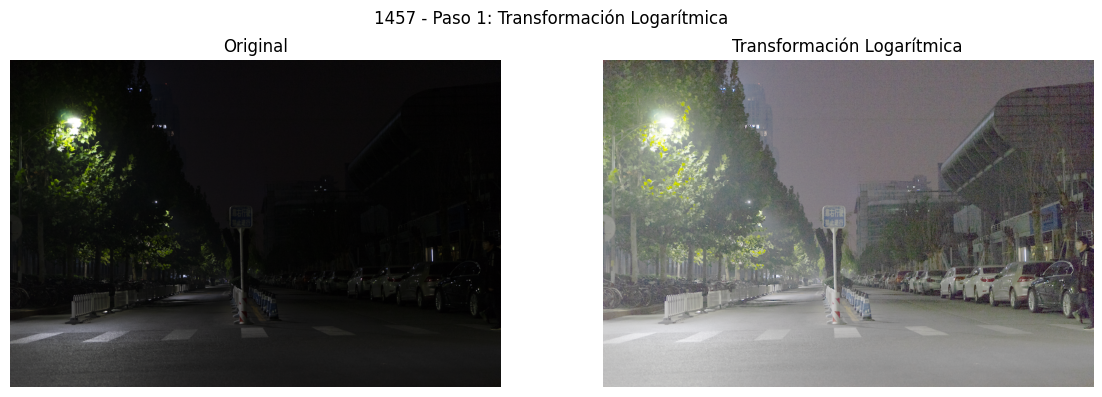

In [82]:
# Paso 1: Transformacion Logaritmica (s = c*log10(1+r))
# c = 255/log10(256) normaliza la salida al rango [0, 255].

c_log = 255 / np.log10(1 + 255)
step1 = np.uint8(np.clip(c_log * np.log10(1 + img_rgb.astype(np.float32)), 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(step1); axes[1].set_title('Transformación Logarítmica'); axes[1].axis('off')
plt.suptitle('1457 - Paso 1: Transformación Logarítmica', fontsize=12)
plt.tight_layout()
plt.show()

## 3.3 Paso 2 - CLAHE LAB

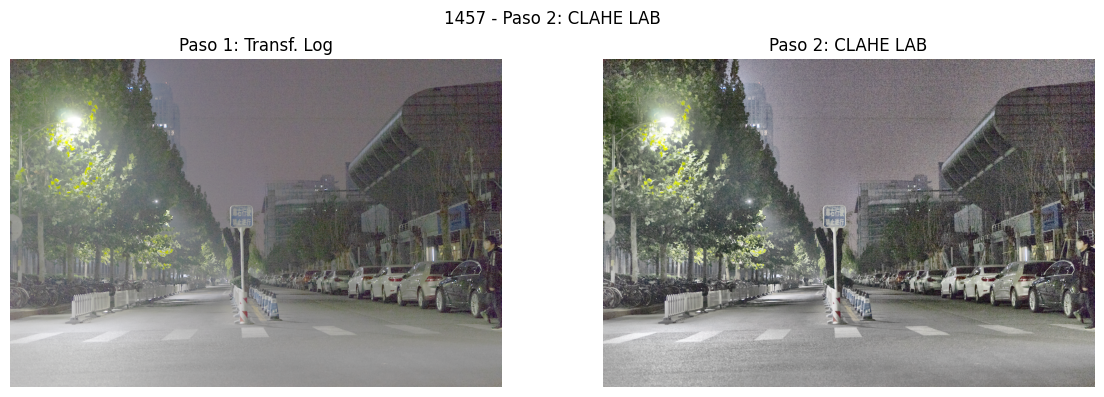

In [83]:
# Paso 2: CLAHE LAB
# clipLimit=2.0, tileGridSize=(8,8): parametros estandar.

step2 = clahe_lab(step1, clip_limit=2.0, tile_grid=(8, 8))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(step1); axes[0].set_title('Paso 1: Transf. Log'); axes[0].axis('off')
axes[1].imshow(step2); axes[1].set_title('Paso 2: CLAHE LAB'); axes[1].axis('off')
plt.suptitle('1457 - Paso 2: CLAHE LAB', fontsize=12)
plt.tight_layout()
plt.show()

## 3.4 Validación

La validación se representa sobre el canal L* de Lab mediante histogramas y CDF.

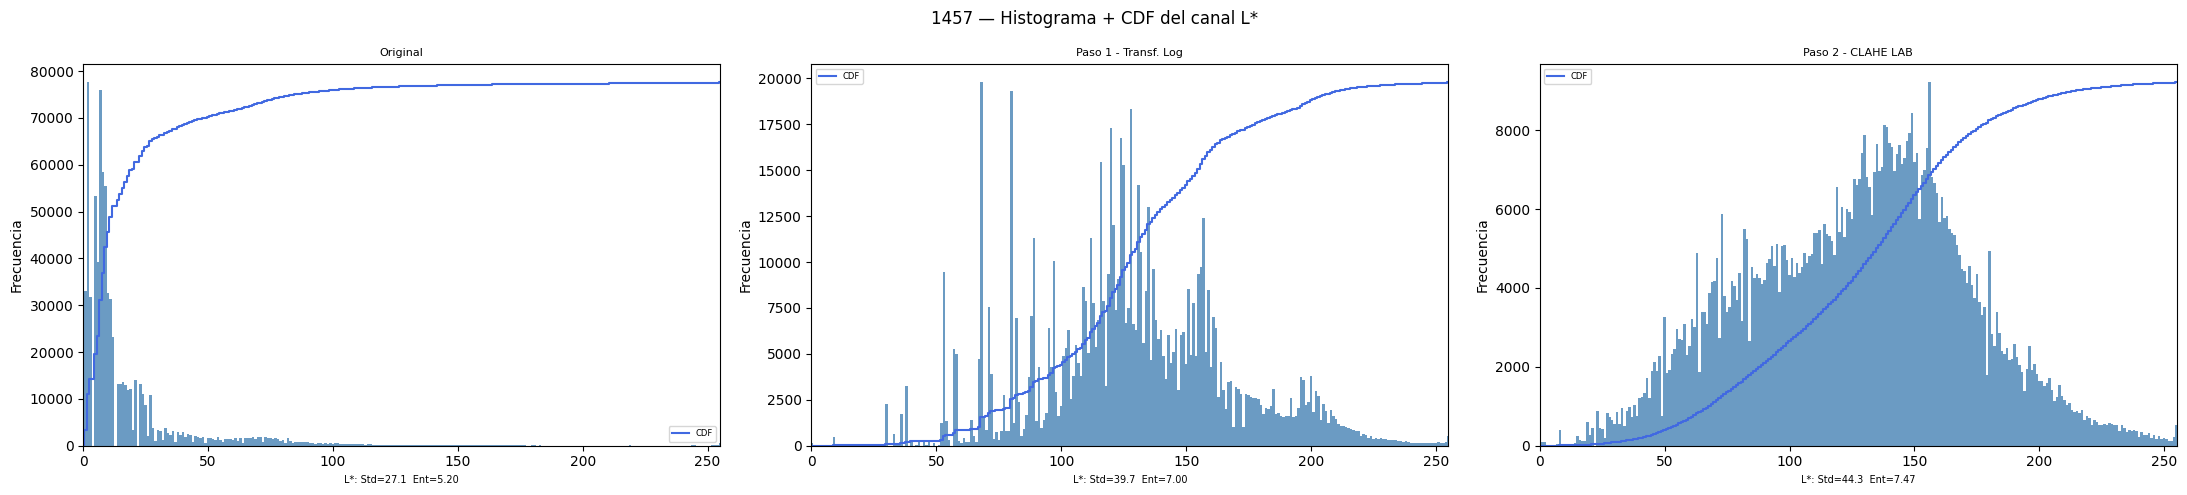

In [ ]:
stages_1457 = {
    'Original': img_rgb,
    'Paso 1 - Transf. Log': step1,
    'Paso 2 - CLAHE LAB': step2,
}
show_validation_histograms(stages_1457, '1457')

# Imagen 4: 1619.png

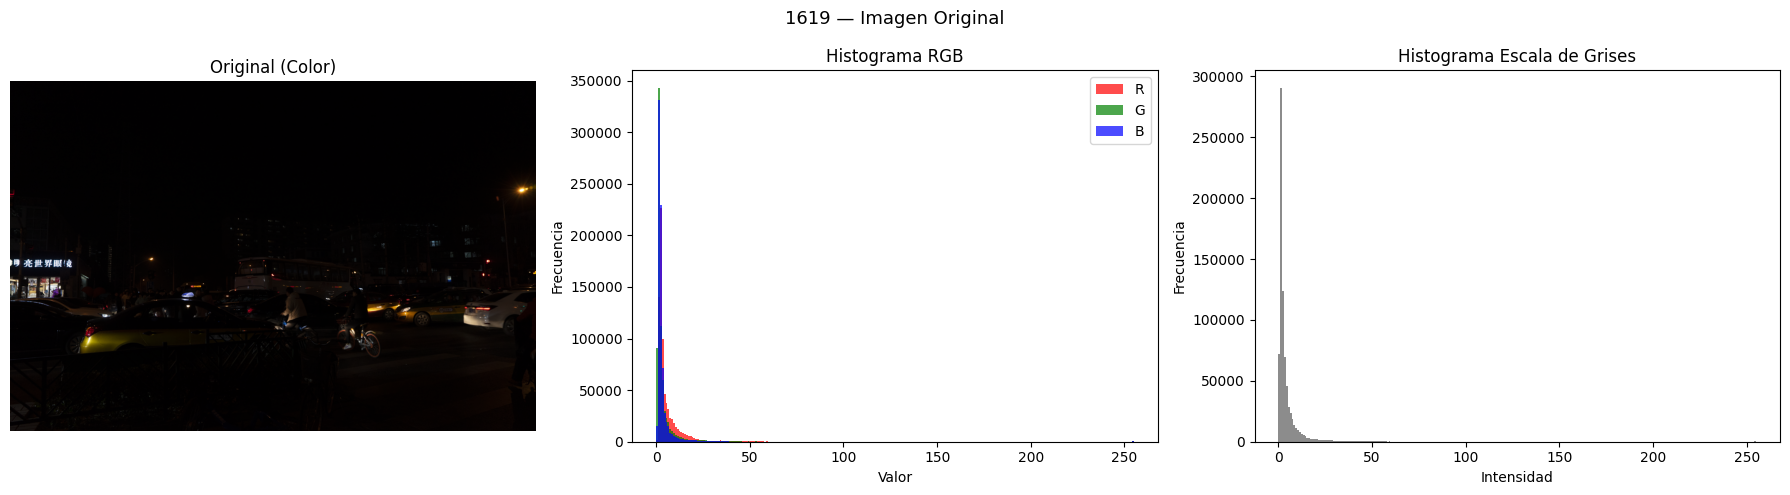

Resolución: 720×1080  |  Rango: [0, 255]  |  Media: 5.4  |  Std: 16.5


In [85]:
# ── Carga ─────────────────────────────────────────────────────────────────────
img_bgr  = cv2.imread("./images/1619.png")
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ── Visualización original + histogramas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original (Color)")
axes[0].axis("off")

for i, (c, label) in enumerate(zip("rgb", ("R", "G", "B"))):
    axes[1].hist(img_rgb[:, :, i].flatten(), bins=256, color=c, alpha=0.7, label=label)
axes[1].set_title("Histograma RGB")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

axes[2].hist(img_gray.flatten(), bins=256, color="gray", alpha=0.9)
axes[2].set_title("Histograma Escala de Grises")
axes[2].set_xlabel("Intensidad")
axes[2].set_ylabel("Frecuencia")

plt.suptitle("1619 — Imagen Original", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Resolución: {img_gray.shape[0]}×{img_gray.shape[1]}  |  "
      f"Rango: [{img_gray.min()}, {img_gray.max()}]  |  "
      f"Media: {img_gray.mean():.1f}  |  Std: {img_gray.std():.1f}")


## 4.1 Objetivo del Proceso

Capturar la información relevante de la imagen original **`1619.png`** para facilitar la extracción de información posterior.

El procesado se estructura en un flujo de dos pasos encadenados:

| Paso | Técnica | Propósito |
|------|---------|----------|
| **1** | Transformación Logarítmica | Expandir el rango de los píxeles oscuros de forma no lineal |
| **2** | CLAHE LAB | Mejora de contraste local en espacio perceptual CIE-Lab |

## 4.2 Paso 1 - Transformación Logarítmica

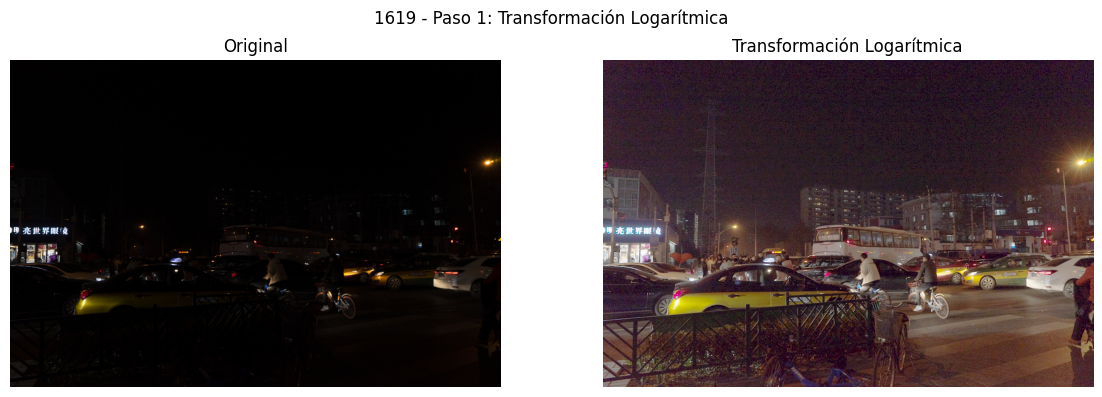

In [86]:
# Paso 1: Transformacion Logaritmica (s = c*log10(1+r))
# c = 255/log10(256) normaliza la salida al rango [0, 255].

c_log = 255 / np.log10(1 + 255)
step1 = np.uint8(np.clip(c_log * np.log10(1 + img_rgb.astype(np.float32)), 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(step1); axes[1].set_title('Transformación Logarítmica'); axes[1].axis('off')
plt.suptitle('1619 - Paso 1: Transformación Logarítmica', fontsize=12)
plt.tight_layout()
plt.show()

## 4.3 Paso 2 - CLAHE LAB

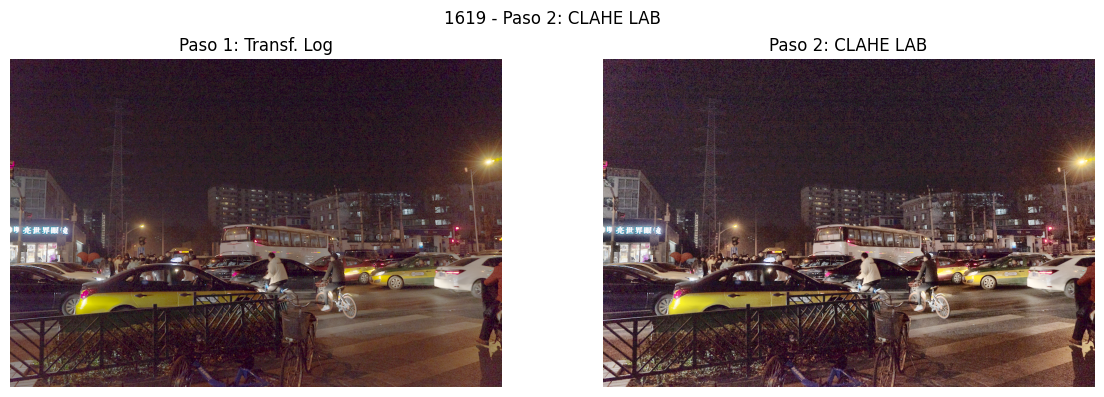

In [87]:
# Paso 2: CLAHE LAB
# clipLimit=2.0, tileGridSize=(8,8): parametros estandar.

step2 = clahe_lab(step1, clip_limit=2.0, tile_grid=(8, 8))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(step1); axes[0].set_title('Paso 1: Transf. Log'); axes[0].axis('off')
axes[1].imshow(step2); axes[1].set_title('Paso 2: CLAHE LAB'); axes[1].axis('off')
plt.suptitle('1619 - Paso 2: CLAHE LAB', fontsize=12)
plt.tight_layout()
plt.show()

## 4.4 Validación

La validación se representa sobre el canal L* de Lab mediante histogramas y CDF.

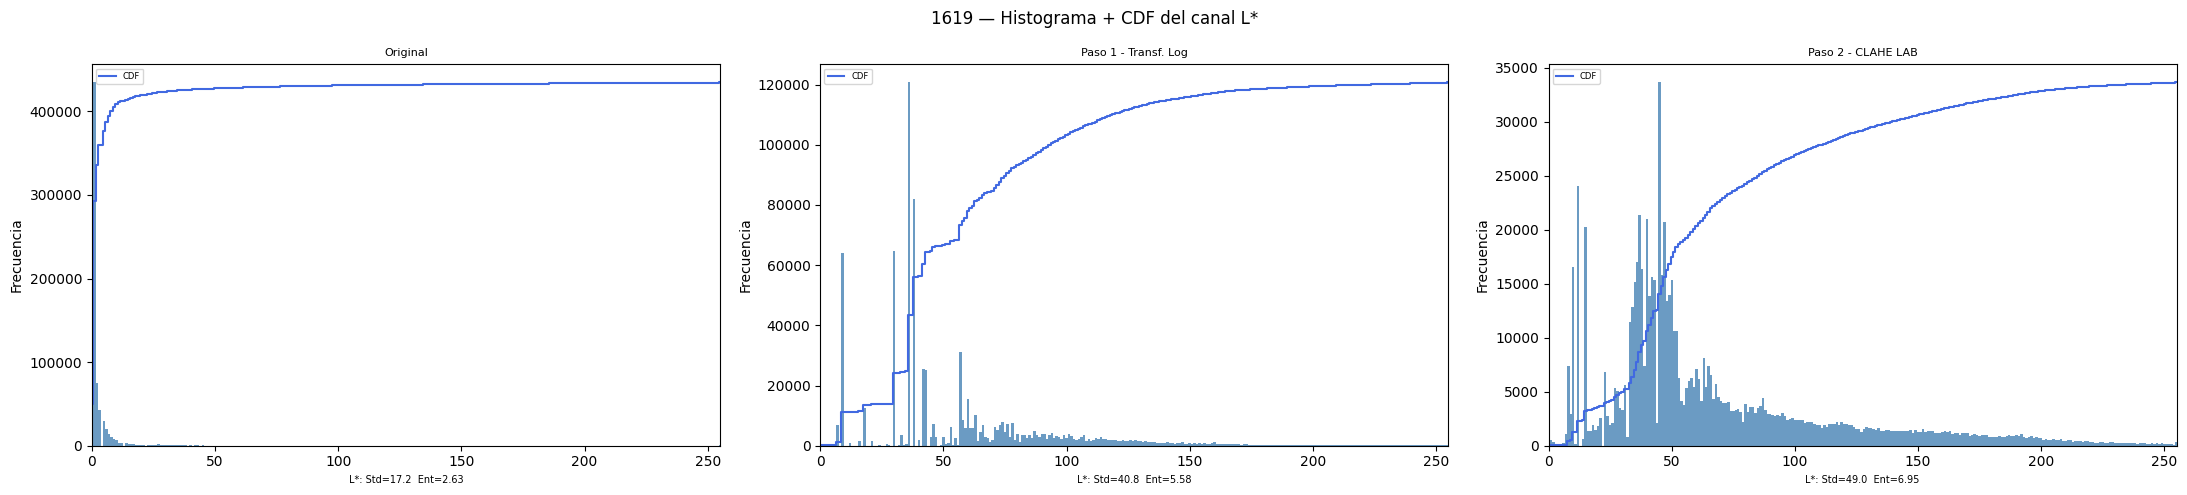

In [ ]:
stages_1619 = {
    'Original': img_rgb,
    'Paso 1 - Transf. Log': step1,
    'Paso 2 - CLAHE LAB': step2,
}
show_validation_histograms(stages_1619, '1619')

In [96]:
# Exportación de figuras para el informe LaTeX
from pathlib import Path

out_dir = Path('./doc/figures')
out_dir.mkdir(parents=True, exist_ok=True)

def save_visual_triplet(stages, image_id):
    items = list(stages.items())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, (name, img) in zip(axes, items):
        ax.imshow(img)
        ax.set_title(name)
        ax.axis('off')
    fig.suptitle(f'{image_id} - Comparativa visual por etapas', fontsize=12)
    fig.tight_layout()
    fig.savefig(out_dir / f'fig_{image_id}_visual.png', dpi=180, bbox_inches='tight')
    plt.close(fig)

def save_hist_cdf(stages, image_id):
    fig, axes = plt.subplots(1, len(stages), figsize=(22, 5))
    if len(stages) == 1:
        axes = [axes]

    for ax, (name, img_s) in zip(axes, stages.items()):
        channel = extract_analysis_channel(img_s)
        hist_s = np.bincount(channel.flatten(), minlength=256)
        cdf_s = hist_s.cumsum() / hist_s.sum()
        ax2 = ax.twinx()

        ax.bar(np.arange(256), hist_s, width=1.0, color='steelblue', alpha=0.85)
        ax2.step(np.arange(256), cdf_s, where='mid', color='crimson', linewidth=1.5, label='CDF')

        ax.set_title(name, fontsize=8)
        ax.set_xlabel('Canal L*', fontsize=8)
        ax.set_ylabel('Frecuencia')
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.15)

        ax2.set_ylim(0, 1.02)
        ax2.set_ylabel('CDF', color='crimson')
        ax2.tick_params(axis='y', colors='crimson')
        ax2.legend(loc='lower right', fontsize=6)

    fig.suptitle(f'{image_id} — Histograma + CDF del canal L*', fontsize=12)
    fig.tight_layout()
    fig.savefig(out_dir / f'fig_{image_id}_hist.png', dpi=180, bbox_inches='tight')
    plt.close(fig)

all_stages = {
    '1187': stages_1187,
    '1321': stages_1321,
    '1457': stages_1457,
    '1619': stages_1619,
}

for image_id, stages in all_stages.items():
    save_visual_triplet(stages, image_id)
    save_hist_cdf(stages, image_id)

print('Figuras exportadas correctamente en:', out_dir.resolve())
for image_id in all_stages:
    print('-', out_dir / f'fig_{image_id}_visual.png')
    print('-', out_dir / f'fig_{image_id}_hist.png')

Figuras exportadas correctamente en: C:\Users\javga\Documents\personal\workspace\unir-ia-va\act1-va\doc\figures
- doc\figures\fig_1187_visual.png
- doc\figures\fig_1187_hist.png
- doc\figures\fig_1321_visual.png
- doc\figures\fig_1321_hist.png
- doc\figures\fig_1457_visual.png
- doc\figures\fig_1457_hist.png
- doc\figures\fig_1619_visual.png
- doc\figures\fig_1619_hist.png
